<a href="https://colab.research.google.com/github/kimi812/ai_0915/blob/main/1201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --quiet --upgrade nltk

import nltk, sys, subprocess, importlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.7 MB/s eta 0:00:00


In [3]:
subprocess.run(["pip", "install", "--quiet", "--upgrade", "nltk"])
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
#---------測試--------------
from nltk.tokenize import sent_tokenize, word_tokenize

txt = "Hello Mr. Smith! NLTK 最近改版了。"
print(sent_tokenize(txt))
print(word_tokenize(txt))


['Hello Mr. Smith!', 'NLTK 最近改版了。']
['Hello', 'Mr.', 'Smith', '!', 'NLTK', '最近改版了。']


In [5]:
#安裝
!apt-get update -qq
!apt-get install -y fonts-noto-cjk
!fc-cache -f -v


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 57 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Fetched 61.2 MB in 2s (26.7 MB/s)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1

['Hello Mr. Smith, how are you doing today?', 'The weather is great, and Python is awesome.', 'The sky is pinkish-blue.', "You shouldn't eat cardboard."]
['Hello', 'Mr.', 'Smith', ',', 'how', 'are', 'you', 'doing', 'today', '?', 'The', 'weather', 'is', 'great', ',', 'and', 'Python', 'is', 'awesome', '.', 'The', 'sky', 'is', 'pinkish-blue', '.', 'You', 'should', "n't", 'eat', 'cardboard', '.']
[('is', 3), ('.', 3)]


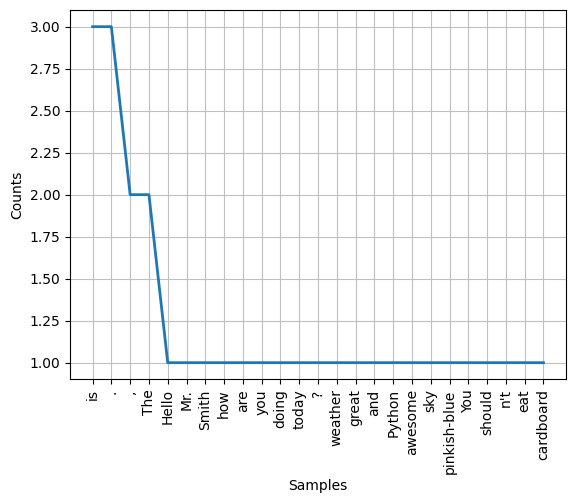

In [6]:
#------------------英文句字本文分析----本機 colab 有路徑與權限問題--------------
import nltk
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.probability import FreqDist

text = """Hello Mr. Smith, how are you doing today?
The weather is great, and Python is awesome.
The sky is pinkish-blue. You shouldn't eat cardboard."""

# 句子斷詞
tokenized_text = sent_tokenize(text)
print(tokenized_text)

# 單字斷詞
tokenized_word = word_tokenize(text)
print(tokenized_word)

# 字詞頻率
fdist = FreqDist(tokenized_word)
print(fdist.most_common(2))

# 畫出前 30 高頻詞
fdist.plot(30, cumulative=False)
plt.show()

In [7]:
import pandas as pd

text = "Hello Mr. Smith, how are you doing today? \
    The weather is great, and Python is awesome. \
        The sky is pinkish-blue. You shouldn't eat cardboard."

mytext=[]
new=[]
onlytext=[]
mytext=text.split(' ')
onlytext= list(dict.fromkeys(mytext))
for i in onlytext :
     new.append(mytext.count(i))
ok=list(zip(onlytext,new))
df = pd.DataFrame(list(zip(onlytext, new)), columns =['字詞', '次數'])
print(df)


               字詞  次數
0           Hello   1
1             Mr.   1
2          Smith,   1
3             how   1
4             are   1
5             you   1
6           doing   1
7          today?   1
8                  12
9             The   2
10        weather   1
11             is   3
12         great,   1
13            and   1
14         Python   1
15       awesome.   1
16            sky   1
17  pinkish-blue.   1
18            You   1
19      shouldn't   1
20            eat   1
21     cardboard.   1


In [8]:
#----------------READ--------------------
# 步驟1. 上傳檔案
import pandas as pd
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
# 步驟2. 讀檔（請根據實際編碼修改 encoding, 常見 utf-8/ansi/big5）
with open(filename, mode="r", encoding="UTF-8") as fn:
 text = fn.read()
mytext=[]
new=[]
onlytext=[]
mytext=text.split(' ')
onlytext= list(dict.fromkeys(mytext))
for i in onlytext :
 new.append(mytext.count(i))
ok=list(zip(onlytext,new))
df = pd.DataFrame(list(zip(onlytext, new)), columns =['字詞', '次數'])
print(df)

Saving 1201.txt to 1201.txt
               字詞  次數
0           Hello   1
1             Mr.   1
2          Smith,   1
3             how   1
4             are   1
5             you   1
6           doing   1
7          today?   1
8                   8
9             The   2
10        weather   1
11             is   3
12         great,   1
13            and   1
14         Python   1
15       awesome.   1
16            sky   1
17  pinkish-blue.   1
18            You   1
19      shouldn't   1
20            eat   1
21   cardboard.\n   1


In [9]:
#-----------------------拆解------------------------
import urllib.request
import pandas as pd
import re
import matplotlib.pyplot as plt
import jieba
x = urllib.request.urlopen('https://www.cycu.edu.tw/')
html = x.read( ).decode('utf-8')
def remove_html_tags(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

html=remove_html_tags(html)
html = re.sub(r'\s', '', html)
mych=re.compile(r'[^\u4e00-\u9fa5]')
html=re.sub(mych, '',html)

stoptext = ''
for words in html:
    stoptext += "/"+words
allword=stoptext.split('/')
onlyword=list(set(allword))
myvalue=[]
for x in onlyword:
    myvalue.append(allword.count(x))

    df = pd.DataFrame(list(zip(onlyword, myvalue)), columns =['字詞', '次數'])
print(df.nlargest(100,'次數'))

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")


    字詞   次數
649  學  362
178  中  121
153  的  102
262  系   93
624  原   90
..  ..  ...
386  鍵   13
460  檢   13
484  連   13
488  研   13
521  態   13

[100 rows x 2 columns]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  fig.canvas

    字詞   次數
648  學  362
177  中  121
152  的  102
261  系   93
623  原   90
624  程   81
402  大   73
11   士   59
680  位   58
35   教   51
329  生   47
232  工   43
264  新   41
58   院   41
665  資   41
72   與   39
710  有   38
282  校   37
10   訊   34
611  育   33
184  國   33
147  件   32
561  素   31
5    動   31
271  元   30
272  事   30
128  設   29
726  用   29
286  一   27
626  計   26


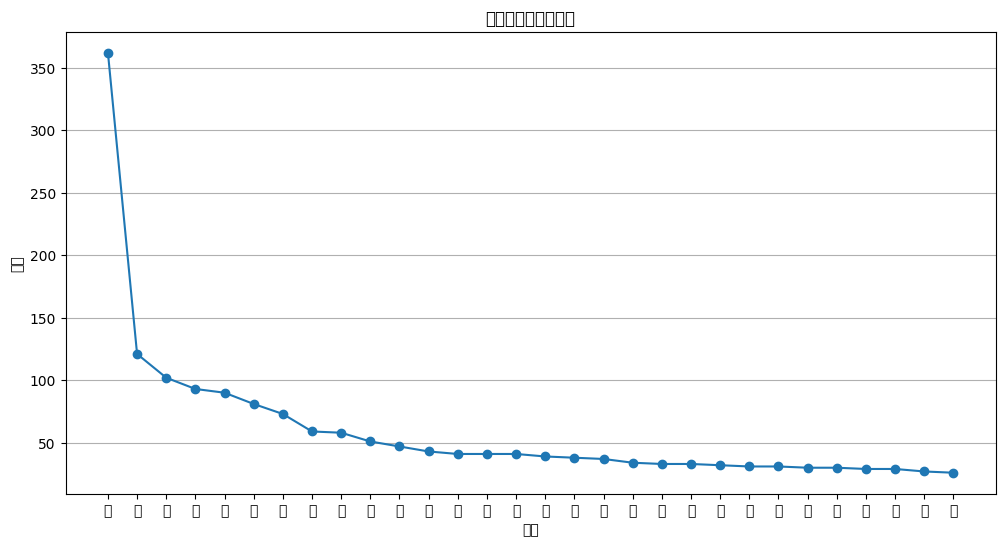

In [10]:
#----------------------圖表---------------------------
import urllib.request
import re
# ---- 必要匯入 ----------------------------------------------------------
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
# ---- 指定中文字型 ------------------------------------------------------
mpl.rcParams["font.family"] = ["Noto Sans CJK JP"]
mpl.rcParams["axes.unicode_minus"] = False # 避免負號亂碼

# 下載與清理網頁內容
x = urllib.request.urlopen('https://www.cycu.edu.tw/')
html = x.read().decode('utf-8')
def remove_html_tags(text):
  clean = re.compile('<.*?>')
  return re.sub(clean, '', text)

html = remove_html_tags(html)
html = re.sub(r'\s', '', html)
mych = re.compile(r'[^\u4e00-\u9fa5]')
html = re.sub(mych, '', html)

# 統計每個字詞出現次數
allword = list(html)
onlyword = list(set(allword))
myvalue = [allword.count(x) for x in onlyword]

df = pd.DataFrame(list(zip(onlyword, myvalue)), columns=['字詞', '次數'])
df = df.sort_values(by='次數', ascending=False)

print(df.head(30)) # 印出前30名

# 畫出前 30 多的字詞出現次數（長條圖，和你圖片很像）
plt.figure(figsize=(12,6))
plt.plot(df['字詞'].head(30), df['次數'].head(30), marker='o') # 折線圖
plt.xlabel('字詞')
plt.ylabel('次數')
plt.title('出現次數最高的字詞')
plt.grid(True, axis='y')
plt.show()

In [12]:
#----------------文本分析 全模式----------------------
import jieba
word = jieba.cut("歡迎來到台灣中壢中原大學", cut_all=0)
print("/".join(word))


歡迎/來/到/台灣/中壢/中原/大學


Saving calcword.txt to calcword (2).txt


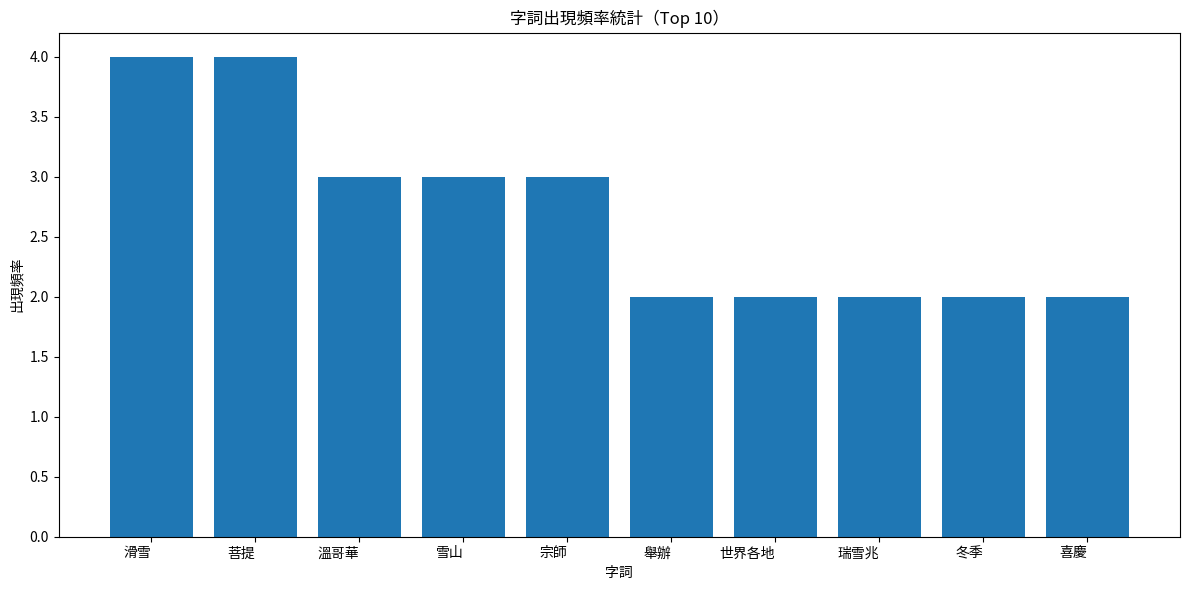

In [16]:
import os, re
import jieba
import numpy as np
import pandas as pd
from collections import Counter
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
# 找 Noto CJK 字型
candidates = [
 "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
 "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
]
# 上傳文字檔（執行後手動選擇 calcword.txt）
from google.colab import files
uploaded = files.upload()# 選 calcword.txt
font_path = next((p for p in candidates if os.path.exists(p)), None)
if font_path:
 fm.fontManager.addfont(font_path)
 plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False
# 讀取剛剛上傳的 calcword.txt（用 UTF-8 BOM 相容的解碼）
with open('calcword.txt', 'r', encoding='utf-8-sig') as f:
 raw = f.read()
# 只保留中文，避免數字/標點造成雜訊
text = re.sub(r'[^\u4e00-\u9fa5]+', ' ', raw)
# 精確模式斷詞並過濾太短的 token（例如單字）
tokens = [w for w in jieba.cut(text, cut_all=False) if len(w.strip()) >= 2]
# 統計與排序
counts = Counter(tokens)
df = pd.DataFrame(counts.items(), columns=['字詞', '次數']).sort_values('次數', ascending=False).reset_index(drop=True)
N = 10
top = df.head(N)
# 畫直條圖（不指定顏色）
plt.figure(figsize=(12, 6))
plt.bar(top['字詞'], top['次數'])
plt.title('字詞出現頻率統計（Top {0}）'.format(N))
plt.xlabel('字詞')
plt.ylabel('出現頻率')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()







In [15]:
!pip install -U pandas-datareader
!pip install -q yfinance


In [18]:
#--------------------一家股票----------------------
import yfinance as myf
import datetime
start_date = datetime.datetime(2025, 11, 1)
end_date = datetime.datetime(2025, 12, 1)
mydata = myf.download("2330.TW", start=start_date, end=end_date, progress=False)
mydata.index = mydata.index.strftime('%Y/%m/%d')
print(mydata)


Price        Close    High     Low    Open    Volume
Ticker     2330.TW 2330.TW 2330.TW 2330.TW   2330.TW
Date                                                
2025/11/03  1510.0  1520.0  1490.0  1510.0  29118770
2025/11/04  1505.0  1525.0  1495.0  1520.0  33925673
2025/11/05  1460.0  1485.0  1455.0  1480.0  56305422
2025/11/06  1465.0  1480.0  1465.0  1470.0  27411394
2025/11/07  1460.0  1465.0  1455.0  1460.0  20329390
2025/11/10  1475.0  1485.0  1465.0  1470.0  25281744
2025/11/11  1465.0  1495.0  1465.0  1490.0  22444166
2025/11/12  1475.0  1485.0  1460.0  1470.0  23642502
2025/11/13  1460.0  1470.0  1460.0  1460.0  21255597
2025/11/14  1430.0  1440.0  1425.0  1425.0  26861702
2025/11/17  1445.0  1460.0  1445.0  1450.0  26602730
2025/11/18  1405.0  1435.0  1405.0  1435.0  42198432
2025/11/19  1395.0  1415.0  1395.0  1400.0  35591948
2025/11/20  1455.0  1460.0  1440.0  1450.0  25964403
2025/11/21  1385.0  1405.0  1385.0  1395.0  54518246
2025/11/24  1375.0  1405.0  1375.0  1400.0  79

/tmp/ipython-input-35082569.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  mydata = myf.download("2330.TW", start=start_date, end=end_date, progress=False)


In [21]:
#-------------------儲存檔案-----------------
import yfinance as myf
import datetime
import pandas as pd
from google.colab import files

# 參數
start_date = datetime.datetime(2025, 11, 1)
end_date  = datetime.datetime(2025, 12, 1)
stock_code = "2306.HK"

# 下載
df = myf.download(stock_code, start=start_date, end=end_date, progress=False)
if df.empty:
  raise ValueError(f"下載不到資料：{stock_code}")

# 日期欄格式與名稱
df.index = pd.to_datetime(df.index).strftime('%Y/%m/%d')
df.index.name = "Date"

# 檔名與暫存路徑
filename = f"{stock_code}_{start_date:%Y%m%d}_{end_date:%Y%m%d}.csv"
tmp_path = f"/content/{filename}"

# 儲存並觸發下載（UTF-8-SIG 便於 Excel 開啟）
df.to_csv(tmp_path, encoding="utf-8-sig")
files.download(tmp_path)
print("已觸發下載：", filename)

/tmp/ipython-input-4071802507.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = myf.download(stock_code, start=start_date, end=end_date, progress=False)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

已觸發下載： 2306.HK_20251101_20251201.csv
